Found 3374 files belonging to 3 classes.
Using 2700 files for training.
Found 3374 files belonging to 3 classes.
Using 674 files for validation.
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step - accuracy: 0.6507 - loss: 0.7934 - val_accuracy: 0.6929 - val_loss: 0.6946
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.6734 - loss: 0.7018 - val_accuracy: 0.6929 - val_loss: 0.6900
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step - accuracy: 0.6772 - loss: 0.6911 - val_accuracy: 0.6929 - val_loss: 0.6877
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.6708 - loss: 0.6933 - val_accuracy: 0.6929 - val_loss: 0.6916
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step - accuracy: 0.6865 - loss: 0.6685 - val_accuracy: 0.6929 - val_loss: 0.6877
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.6762 - loss: 0.6663 - val_accuracy: 0.6899 - val_loss: 0.7144
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 212ms/step - accuracy: 0.6942 - loss: 0

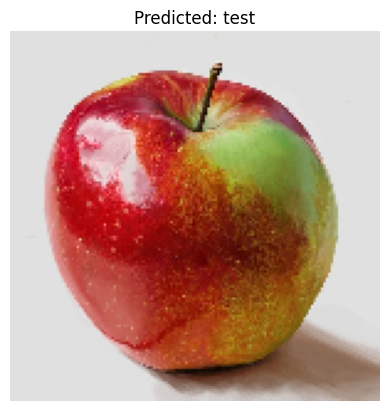

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load dataset
dataset_path = r"C:\aslam\MY_data"

# Example: 'dataset/'
train_ds = image_dataset_from_directory(dataset_path, validation_split=0.2, subset='training', seed=123, image_size=(150, 150), batch_size=32)
val_ds = image_dataset_from_directory(dataset_path, validation_split=0.2, subset='validation', seed=123, image_size=(150, 150), batch_size=32)

# Define CNN Model
model = keras.Sequential([
   keras.Input(shape=(150, 150, 3)),
layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(train_ds.class_names), activation='softmax')  # Number of classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# Evaluate the model
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Predict on a new image
# Predict on a new image
img_path = r"C:\aslam\dusky-jun-10.jpg"
img = keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)
predicted_class = train_ds.class_names[np.argmax(prediction)]

print(f"Predicted Class: {predicted_class}")

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()